----

----

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

In [1]:
# Importar librerías

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv(r'C:\Users\Sandy Alonso\OneDrive\Documentos\Python_Sandy\Curso Triple Ten\Curso_Triple_Ten_2\Sprint_8_proyecto_final_8\novaretail_comportamiento_clientes_2024.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), str(3)
memory usage: 1.4 MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# Se muestran las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparación de datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad': Estaba codificada como float64 pero fue convertida a int64 pues representa valores enteros.

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corrección del tipo de dato
df['edad'] = df['edad'].astype('int64')

In [5]:
# Verificación de cambios
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 1.4 MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion',  'ingreso_anual']].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


**Comentario**:

Diagnóstico inicial de variables numéricas

- 'edad' - Estaba codificada como float64 y fue convertida a int64 ya que en esta columna debe haber números enteros.
- 'ingreso_anual' - Presenta valores mínimos de 0.00, es posible que se trate de sentinel values.
- 'gasto_publicidad_dirigida' - Presenta valores mínimos de 0.00 puede tratarse de valores reales o sentinel values.

#### Explorar variables binarias

In [7]:
# Se verifica que cada columna tenga únicamente dos valores posibles

print(df['miembro_premium'].unique())
print(df['miembro_premium'].value_counts())

print(df['abandono'].unique())
print(df['abandono'].value_counts())

[0 1]
miembro_premium
0    12911
1     2089
Name: count, dtype: int64
[0 1]
abandono
0    12739
1     2261
Name: count, dtype: int64


**Comentario**:

Diagnóstico inicial de variables binarias

- `miembro_premium` — Contienen solamente valores 0 y 1 con la modificación que se hizo.
- `abandono` — Contiene solamente valores 0 y 1 y está correctamente codificada.

#### Exploración de variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
print(df['tipo_dispositivo'].nunique())
print(df['region'].nunique())

3
4


In [9]:
# Explorar variables categóricas y cómo se distribuyen
print(df['tipo_dispositivo'].value_counts())
print(df['region'].value_counts())

tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: count, dtype: int64
region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64


**Comentario**:

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — La mayoría de clientes usa móvil (9,818), seguido de escritorio (3,720) y tablet (1,462).
- 'region' - La región norte concentra más clientes (4,395) y la región este tiene menos (3,069).
- 'id_cliente' - Es un identificador único por cliente, no será utilizado como variable analítica.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.
  
  - Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.
Los valores de 0.00 en ingreso_anual se conservan en el dataset pero se documentan como posibles sentinel values, ya que es sospechoso que un cliente genere cero ingresos.

**Supuesto central:**  
Este análisis identifica relaciones entre variables


## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

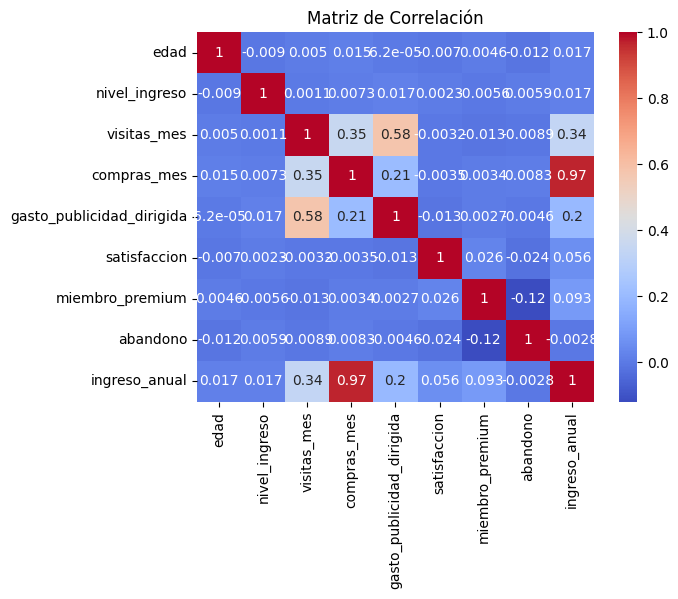

In [10]:
# Visualizamos la matriz de correlación para identificar relaciones
matriz_corr = df.corr(numeric_only=True)
sns.heatmap(matriz_corr, annot = True, cmap = 'coolwarm',)
plt.title('Matriz de Correlación')
plt.show()

**Comentario**:


Observaciones generales (Heatmap)  
Se observa una correlación negativa débil entre 'miembro_premium' y 'abandono' (-0.12)


Observaciones respecto a `ingreso_anual`  
- - En el heatmap se observa una correlación bastante fuerte de 'ingreso_anual' con 'compras_mes' (0.97)
- Entre 'ingreso_anual' y 'visitas_mes' hay una correlación moderada (0.34)


### Scatterplot general

**Gráfico**

  - Entre ingreso_anual y compras_mes se observa una correlación positiva, entre compras_mes y visitas_mes, hay una correlación moderada.
  - Entre ingreso_anual y visitas mes, los puntos están muy dispersos, lo confirma la relación moderada (0.34).

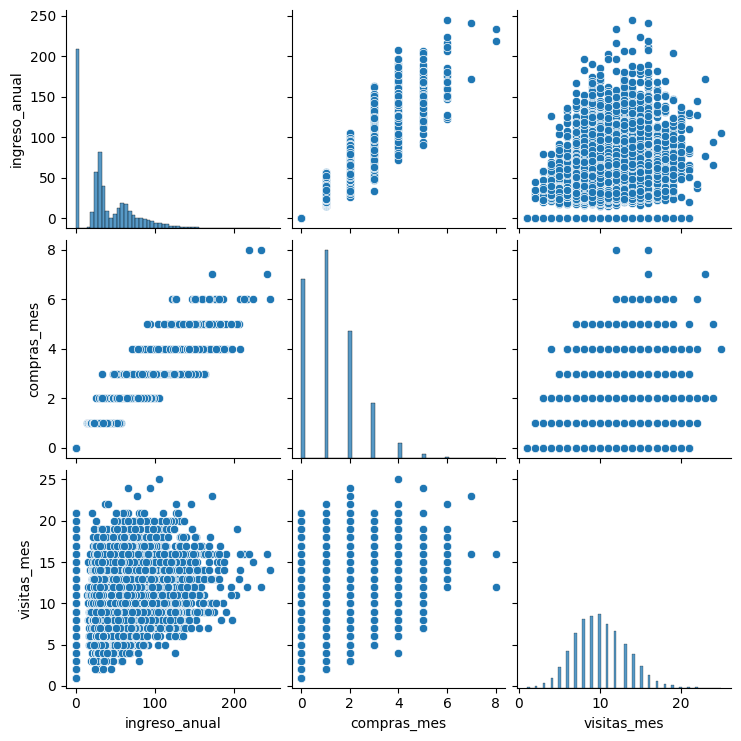

In [11]:
sns.pairplot(df[['ingreso_anual', 'compras_mes', 'visitas_mes']])
plt.show()

### Scatterplot para pares clave

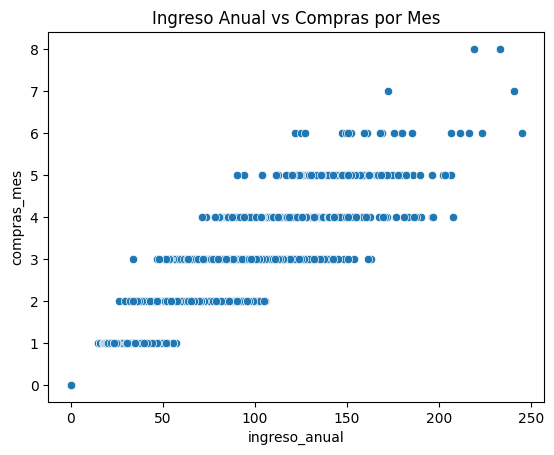

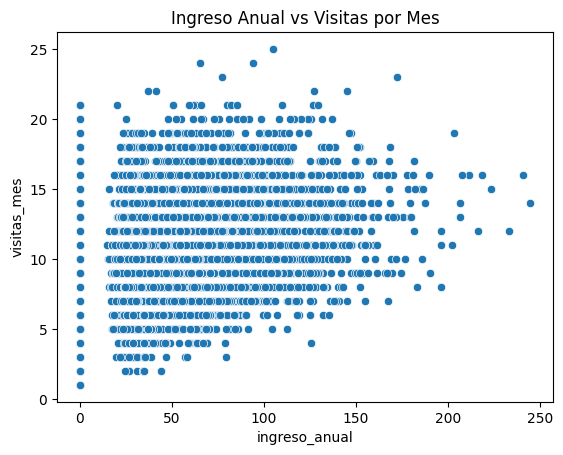

In [18]:
# Visualización pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x='ingreso_anual', y='compras_mes')
plt.title('Ingreso Anual vs Compras por Mes')
plt.show()

sns.scatterplot(data=df, x='ingreso_anual', y='visitas_mes')
plt.title('Ingreso Anual vs Visitas por Mes')
plt.show()

Observaciones iniciales (Scatterplot)

**ingreso_anual vs compras_mes**
- Dirección: En Ingreso Anual vs Compras por Mes se observa claramente la correlación entre ambas columnas, corresponde con el  (0.97) observado en el heatmap y scatterplot general. También observamos la presencia de outliers hacia la derecha.


**ingreso_anual vs visitas_mes**
- Dirección: En Ingreso Anual vs Visitas por Mes, igualmente podemos comprobar una correlación moderada entre ambas columnas(0.34). La dispersión es moderada con algunos outliers igualmente hacia la derecha.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [19]:
# Calcular correlación entre variables relevantes
print(df['ingreso_anual'].corr(df['compras_mes'], method = 'pearson'))
print(df['ingreso_anual'].corr(df['compras_mes'], method = 'spearman'))

0.9671485435708543
0.9674824920326731


In [20]:
# Calcular correlación entre variables relevantes
print(df['ingreso_anual'].corr(df['visitas_mes'], method = 'pearson'))
print(df['ingreso_anual'].corr(df['visitas_mes'], method = 'spearman'))

0.337146643249875
0.3209536973769648


Observaciones de correlación

ingreso_anual vs compras_mes

Correlación: Pearson = 0.967 y Spearman = 0.967. Ambos coeficientes son prácticamente idénticos, lo que indica que la relación no solo es fuerte, sino también lineal — a mayor ingreso anual, las compras mensuales aumentan de forma consistente y proporcional.

ingreso_anual vs visitas_mes

Correlación: Pearson = 0.337 y Spearman = 0.321. Los valores son cercanos entre sí, lo que sugiere una relación moderada que es mayormente monótona, aunque con algo más de dispersión que el par anterior (consistente con lo observado en el scatterplot). No se confirma causalidad.

### Punto-biserial

In [21]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

print(pointbiserialr(df['ingreso_anual'], df['miembro_premium']))
print(pointbiserialr(df['ingreso_anual'], df['abandono']))

SignificanceResult(statistic=np.float64(0.09309943961980152), pvalue=np.float64(3.0943076155276592e-30))
SignificanceResult(statistic=np.float64(-0.0028239340216171995), pvalue=np.float64(0.7294691719078358))


**Comentario**: Dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**ingreso_anual vs miembro_premium**
- Relación: Se comparó la correlación entre ingreso_anual y miembro_premium y la correlación es de 0.093, son muy cercanos a cero, esto indica una asociación débil entre ambas variables.
   La membresía premium no está fuertemente asociada con el ingreso generado. 

**ingreso_anual vs abandono**
- Relación: Entre ingreso_anual y abandono y se encontró una correlación de -0.003, lo que también indica una asociación débil entre estas variables.
  El abandono no sugiere una asociación fuerte con el ingreso anual.

### V de Cramér

In [22]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
tabla = pd.crosstab(df['region'], df['tipo_dispositivo'])
print(tabla)

tipo_dispositivo  escritorio  móvil  tablet
region                                     
este                     766   2003     300
norte                   1125   2843     427
oeste                    935   2489     386
sur                      894   2483     349


In [23]:
# Aplicar V de Cramér en variables relevantes
n = len(df)
chi2, p, dof, expected= chi2_contingency(tabla) 
chi2

v_cramer = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
print(v_cramer)

0.012378338407739397


En el análisis se observa un valor de 0.012, lo que indica una asociación muy débil entre región y tipo de dispositivo.
NovaRetail+ puede diseñar una estrategia de dispositivos de manera uniforme para todas las regiones, sin necesidad de personalizar por zona geográfica.
El dataset no contiene más variables categóricas disponibles para aplicar V de Cramér en otros pares.

## Sección 5 - Interpretación de resultados para el negocio

### Hallazgo 1 — ingreso_anual y compras_mes

**Evidencia visual:** El heatmap y el scatterplot de pares clave muestran una relación positiva fuerte entre ambas variables.

**Evidencia numérica:** Pearson = 0.97

**Interpretación** El ingreso anual generado por el cliente presenta una correlación muy fuerte con la cantidad de compras realizadas al mes.

**No podemos afirmar** Que esta relación sea causal. Pueden existir otras variables que estén influyendo en el comportamiento de ambas.

**Implicación de negocio** NovaRetail+ podría diseñar estrategias orientadas a incrementar la frecuencia de compra, como promociones, descuentos por volumen o campañas de reactivación, con el objetivo de aumentar el ingreso generado por cliente. 


### Hallazgo 2 — ingreso_anual y visitas_mes

**Evidencia visual:** El heatmap y el scatterplot de pares clave muestran una relación positiva moderada entre ambas variables.

**Evidencia numérica:** Pearson = 0.337

**Interpretación:** El ingreso anual presenta una correlación moderada con el número de visitas al mes. Ambas variables tienden a moverse en la misma dirección, pero con mayor dispersión que en el Hallazgo 1.

**No podemos afirmar:** Que las visitas al mes causen un aumento en el ingreso anual. Pueden existir otros factores que influyan en esta relación.

**Implicación de negocio:** NovaRetail+ podría explorar estrategias para aumentar la frecuencia de visitas, como notificaciones, contenido personalizado o promociones para sus clientes como un posible indicador asociado al ingreso del cliente. 


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- El dataset presenta valores en 0 en ingreso_anual que podrían ser sentinels o errores de captura. Se tiene que investigar para completar el dato o reemplazarlo.
- El análisis no considera variables no observadas que podrían influir en las relaciones encontradas.
- No se hizo exploración de segmentaciones adicionales (por región, dispositivo o membresía) que podrían revelar patrones distintos.
- Variables como compras_mes y visitas_mes, presentan posible colinealidad, lo que podría afectar la interpretación de manera individual.

### **Próximos pasos** 

Probar segmentación adicional
- Opción 1: Investigar los valores en 0 de ingreso_anual
- Opción 2: Realizar experimentos controlados para evaluar causalidad.